In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/Sahdam/TS_Academy_Capstone_Project/refs/heads/main/Model_Data_set.csv"
df = pd.read_csv(url, parse_dates=["Date"], index_col="Date")
df.head()

,food_cpi,fuel_price,exchange_rate,basket_cost
Date,,,,
2017-01-31,221.4,148.70,305.20,17028.51
2017-02-28,225.8,149.80,305.31,17171.78
2017-03-31,230.8,149.39,306.40,17846.54
2017-04-30,235.5,149.87,306.05,18087.17
2017-05-31,241.5,150.69,305.54,18632.75


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

/tmp/ipykernel_706/2578449925.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="best")
/tmp/ipykernel_706/2578449925.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="best")
/tmp/ipykernel_706/2578449925.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="best")
/tmp/ipykernel_706/2578449925.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(loc="best")


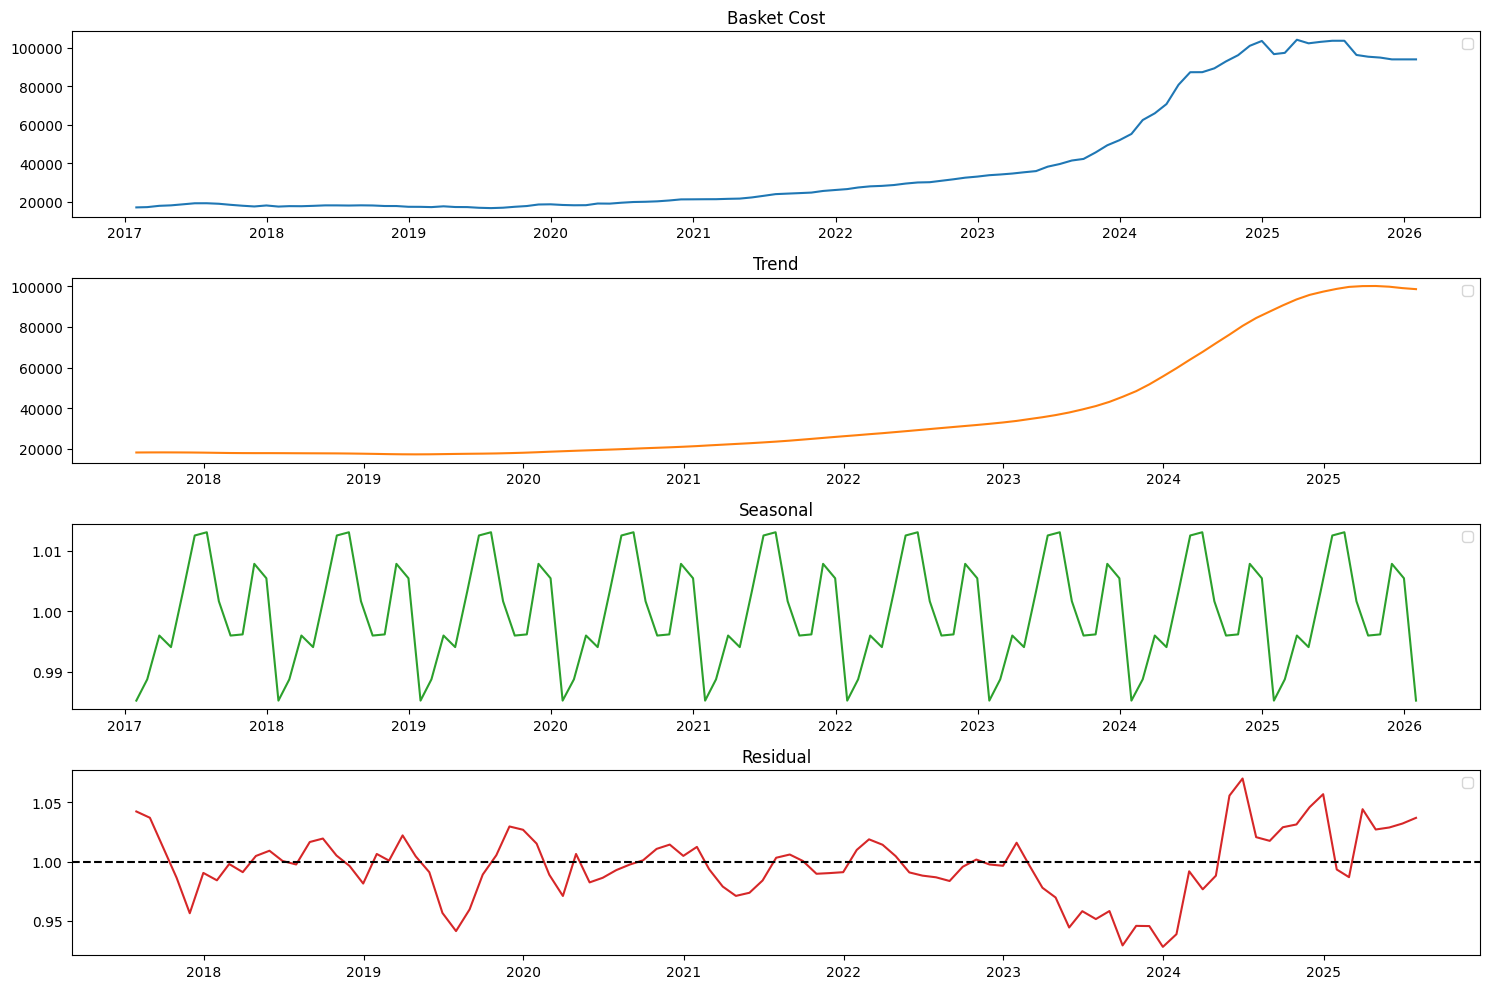

In [9]:
decompose_basket = seasonal_decompose(df["basket_cost"], model="mul", period=12)
trend = decompose_basket.trend
seasonal = decompose_basket.seasonal
residual = decompose_basket.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(df["basket_cost"])
axes[0].legend(loc="best")
axes[0].set_title("Basket Cost")

axes[1].plot(trend, color="C1")
axes[1].legend(loc="best")
axes[1].set_title("Trend")

axes[2].plot(seasonal, color="C2")
axes[2].legend(loc="best")
axes[2].set_title("Seasonal")

axes[3].plot(residual, color="C3")
axes[3].legend(loc="best")
axes[3].set_title("Residual")
plt.axhline(1.0, linestyle="--", color="k")

plt.tight_layout()
plt.show()

/tmp/ipykernel_706/1366912146.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc="best")
/tmp/ipykernel_706/1366912146.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(loc="best")
/tmp/ipykernel_706/1366912146.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc="best")
/tmp/ipykernel_706/1366912146.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend(loc="best")


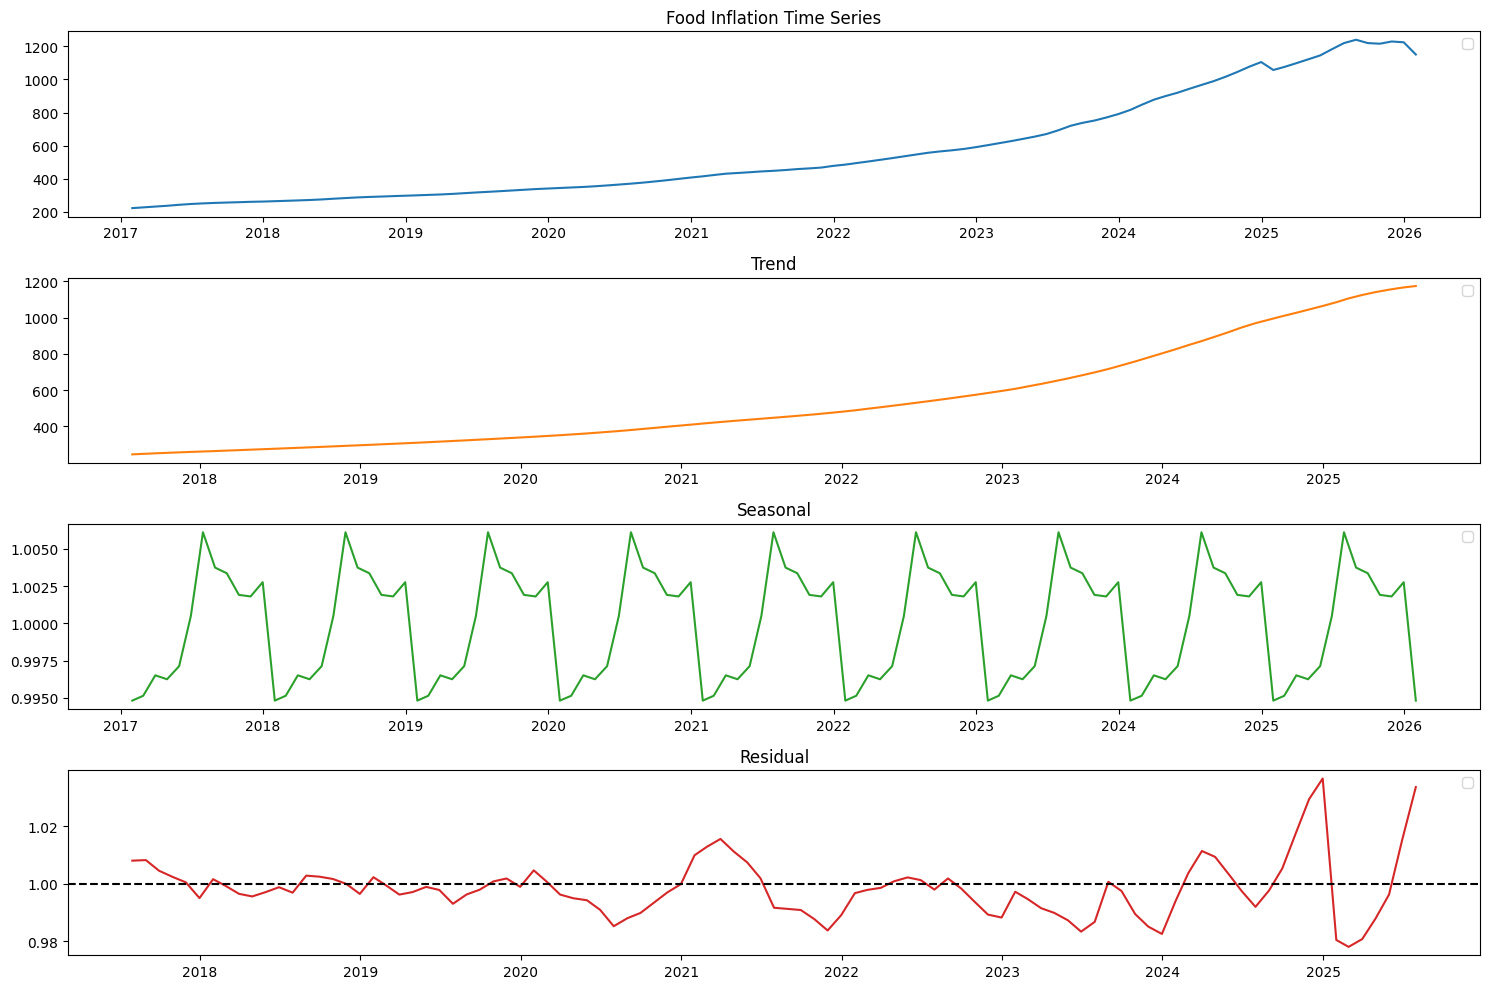

In [10]:
decompose_food = seasonal_decompose(df["food_cpi"], model="mul", period=12)
trend = decompose_food.trend
seasonal = decompose_food.seasonal
residual = decompose_food.resid

fig, axes = plt.subplots(4, 1, figsize=(15, 10))

axes[0].plot(df["food_cpi"])
axes[0].legend(loc="best")
axes[0].set_title("Food Inflation Time Series")

axes[1].plot(trend, color="C1")
axes[1].legend(loc="best")
axes[1].set_title("Trend")

axes[2].plot(seasonal, color="C2")
axes[2].legend(loc="best")
axes[2].set_title("Seasonal")

axes[3].plot(residual, color="C3")
axes[3].legend(loc="best")
axes[3].set_title("Residual")
plt.axhline(1.0, linestyle="--", color="k")

plt.tight_layout()
plt.show()

In [13]:
adf_basket = adfuller(df["basket_cost"].dropna())
print(f"ADF Statistic P_value: {adf_basket[1]:.4f}")

ADF Statistic P_value: 0.8000


In [14]:
adf_food = adfuller(df["food_cpi"].dropna())
print(f"ADF Statistic P_value: {adf_food[1]:.4f}")

ADF Statistic P_value: 0.8183


In [17]:
!pip install pmdarima
from pmdarima.arima.utils import ndiffs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.1 MB/s eta 0:00:00


In [18]:
ndiffs(df["basket_cost"], test='adf')

2

In [19]:
ndiffs(df["food_cpi"], test='adf')

2

In [20]:
basket_diff = df["basket_cost"].diff().diff().dropna()

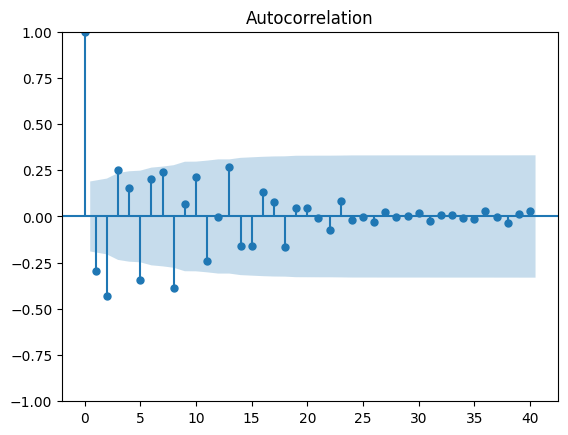

In [21]:
plot_acf(basket_diff, lags=40)
plt.show()